# Notebook 6: Model Training

**Automotive Car Price Prediction Pipeline**

---

This notebook trains 3 regression models and evaluates them on both train and test sets to check for overfitting.

**Input:** `car_price_project.default.preprocessed_data` (from Notebook 5)

**Output:** `car_price_project.default.trained_models` (metrics table)

## 1. Load Preprocessed Data from Catalog

In [0]:
%pip install xgboost scikit-learn --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# Read preprocessed data from catalog
df_spark = spark.table("workspace.default.carprice_project_preprocessed_data")
df = df_spark.toPandas()

print(f"Total shape: {df.shape}")
print(f"Split distribution:")
print(df['split'].value_counts().to_string())

/databricks/python/lib/python3.11/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


Total shape: (56133, 72)
Split distribution:
train    44906
test     11227


In [0]:
# Split back into train and test
train_df = df[df['split'] == 'train'].drop(columns=['split'])
test_df = df[df['split'] == 'test'].drop(columns=['split'])

X_train = train_df.drop(columns=['price']).values
y_train = train_df['price'].values

X_test = test_df.drop(columns=['price']).values
y_test = test_df['price'].values

feature_names = [c for c in train_df.columns if c != 'price']

print(f"Training: X={X_train.shape}, y={y_train.shape}")
print(f"Test:     X={X_test.shape}, y={y_test.shape}")
print(f"Features: {len(feature_names)}")

Training: X=(44906, 70), y=(44906,)
Test:     X=(11227, 70), y=(11227,)
Features: 70


## 2. Define Evaluation Function

In [0]:
from sklearn.metrics import r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and evaluate on both train and test sets."""
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # MAE
    train_mae  = mean_absolute_error(y_train, y_train_pred)
    test_mae   = mean_absolute_error(y_test,  y_test_pred)
    mae_gap    = test_mae - train_mae

    # RMSE  ← primary evaluation metric
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

    # R²  ← reported for information only, NOT used for model selection
    # R² measures what proportion of the variance in car prices the model explains.
    # Variance = how spread out the prices are from their mean value.
    #   R² = 1.0  →  model explains ALL variance (perfect predictions)
    #   R² = 0.0  →  model explains nothing (no better than always predicting the mean price)
    #   R² = 0.68 →  model explains 68% of the spread; 32% is unexplained
    # We report R² so it is visible, but we do NOT use it to rank models because:
    # on a right-skewed price distribution ($100–$235k), R² is artificially inflated
    # by the small number of very expensive luxury cars. A model can score R² > 0.90
    # while still being off by thousands of dollars on everyday mid-range cars.
    # RMSE gives us honest, dollar-interpretable errors and is our primary metric.
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test,  y_test_pred)

    # Overfitting check
    overfit_flag = "OVERFITTING" if mae_gap > train_mae * 0.20 else "OK"

    print(f"\n{'=' * 72}")
    print(f"  {model_name}")
    print(f"{'=' * 72}")
    print(f"{'Metric':<15} {'Train':>12} {'Test':>12}  {'Notes':>25}")
    print(f"{'-' * 72}")
    print(f"{'MAE':<15} ${train_mae:>10,.0f} ${test_mae:>10,.0f}  {'avg dollar error':>25}")
    print(f"{'RMSE (*)':<15} ${train_rmse:>10,.0f} ${test_rmse:>10,.0f}  {'primary metric':>25}")
    print(f"{'R²':<15}  {train_r2:>10.4f}  {test_r2:>10.4f}  {'reported only, not ranked':>25}")
    print(f"\n  (*) RMSE is our primary evaluation metric — penalises large errors more.")
    print(f"  Overfitting check (test MAE > 20% above train MAE): {overfit_flag}")
    print(f"\n  R² interpretation:")
    print(f"  The model explains {test_r2*100:.1f}% of the variance in car prices.")
    print(f"  Variance measures how spread out prices are from the mean (${y_test.mean():,.0f}).")
    print(f"  The remaining {(1-test_r2)*100:.1f}% of price variation is not captured by this model.")


    return {
        'model':       model_name,
        'train_mae':   round(train_mae,  2),
        'train_rmse':  round(train_rmse, 2),
        'test_mae':    round(test_mae,   2),
        'test_rmse':   round(test_rmse,  2),
        'train_r2':    round(train_r2,   4),
        'test_r2':     round(test_r2,    4),
        'mae_gap':     round(mae_gap,    2),
        'overfitting': overfit_flag
    }

## 3. Train Model 1: Linear Regression

In [0]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, X_train, y_train, X_test, y_test, "Linear Regression")


  Linear Regression
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     2,656 $     2,607           avg dollar error
RMSE (*)        $     5,548 $     5,235             primary metric
R²                   0.5603      0.5861  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 58.6% of the variance in car prices.
  Variance measures how spread out prices are from the mean ($7,411).
  The remaining 41.4% of price variation is not captured by this model.


## 4. Train Model 2: Random Forest Regressor

Random Forest was overfitting in initial testing (train MAE ~$445 vs test MAE ~$1,142 — a 157% gap). We resolved this by adding regularisation constraints that prevent the trees from growing too deep and memorising individual training examples.

**Regularisation parameters applied:**
- `max_depth=15` — trees cannot grow beyond 15 levels (previously unlimited)
- `min_samples_split=10` — a node must have at least 10 samples before it can split
- `min_samples_leaf=5` — each leaf must contain at least 5 samples (no single-car leaves)
- `max_features='sqrt'` — each split only considers √(n_features) features (already default, made explicit)

**Result:** Overfitting eliminated — train MAE $1,512 vs test MAE $1,539 

In [0]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,          # limit tree depth to prevent memorisation
    min_samples_split=10,  # need at least 10 samples to make a split
    min_samples_leaf=5,    # each leaf must contain at least 5 cars
    max_features='sqrt',   # consider sqrt(n_features) at each split
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest")


  Random Forest
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     1,512 $     1,539           avg dollar error
RMSE (*)        $     3,446 $     3,382             primary metric
R²                   0.8304      0.8272  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 82.7% of the variance in car prices.
  Variance measures how spread out prices are from the mean ($7,411).
  The remaining 17.3% of price variation is not captured by this model.


## 5. Train Model 3: XGBoost Regressor

In [0]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")


  XGBoost
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     1,159 $     1,219           avg dollar error
RMSE (*)        $     2,098 $     2,551             primary metric
R²                   0.9371      0.9017  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 90.2% of the variance in car prices.
  Variance measures how spread out prices are from the mean ($7,411).
  The remaining 9.8% of price variation is not captured by this model.


## 6. Train Model 4: Decision Tree Regressor

A **Decision Tree** splits the data into smaller and smaller groups by asking a series of yes/no questions about the features. Each internal node is one question (e.g. *"Is car_age ≤ 3.5 years?"*), each branch is the answer, and each leaf is a final price prediction — the average price of all training cars that landed in that leaf.

We train a shallow tree (`max_depth=4`) deliberately:
- A deep tree would memorise every car and overfit badly
- A shallow tree is readable, interpretable, and still captures the main price drivers
- The top 3 nodes of the tree reveal **which features the model considers most important first**

**Why include a Decision Tree?**
Decision Trees are the building block for both Random Forest (100 trees averaged) and XGBoost (100 trees in sequence). Understanding one tree helps explain why the ensemble methods work.

In [0]:
from sklearn.tree import DecisionTreeRegressor, export_text
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Train a shallow Decision Tree (max_depth=4 for readability) ───────────────
dt_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

dt_results = evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")




  Decision Tree
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     2,171 $     2,153           avg dollar error
RMSE (*)        $     4,369 $     4,368             primary metric
R²                   0.7273      0.7118  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 71.2% of the variance in car prices.
  Variance measures how spread out prices are from the mean ($7,411).
  The remaining 28.8% of price variation is not captured by this model.


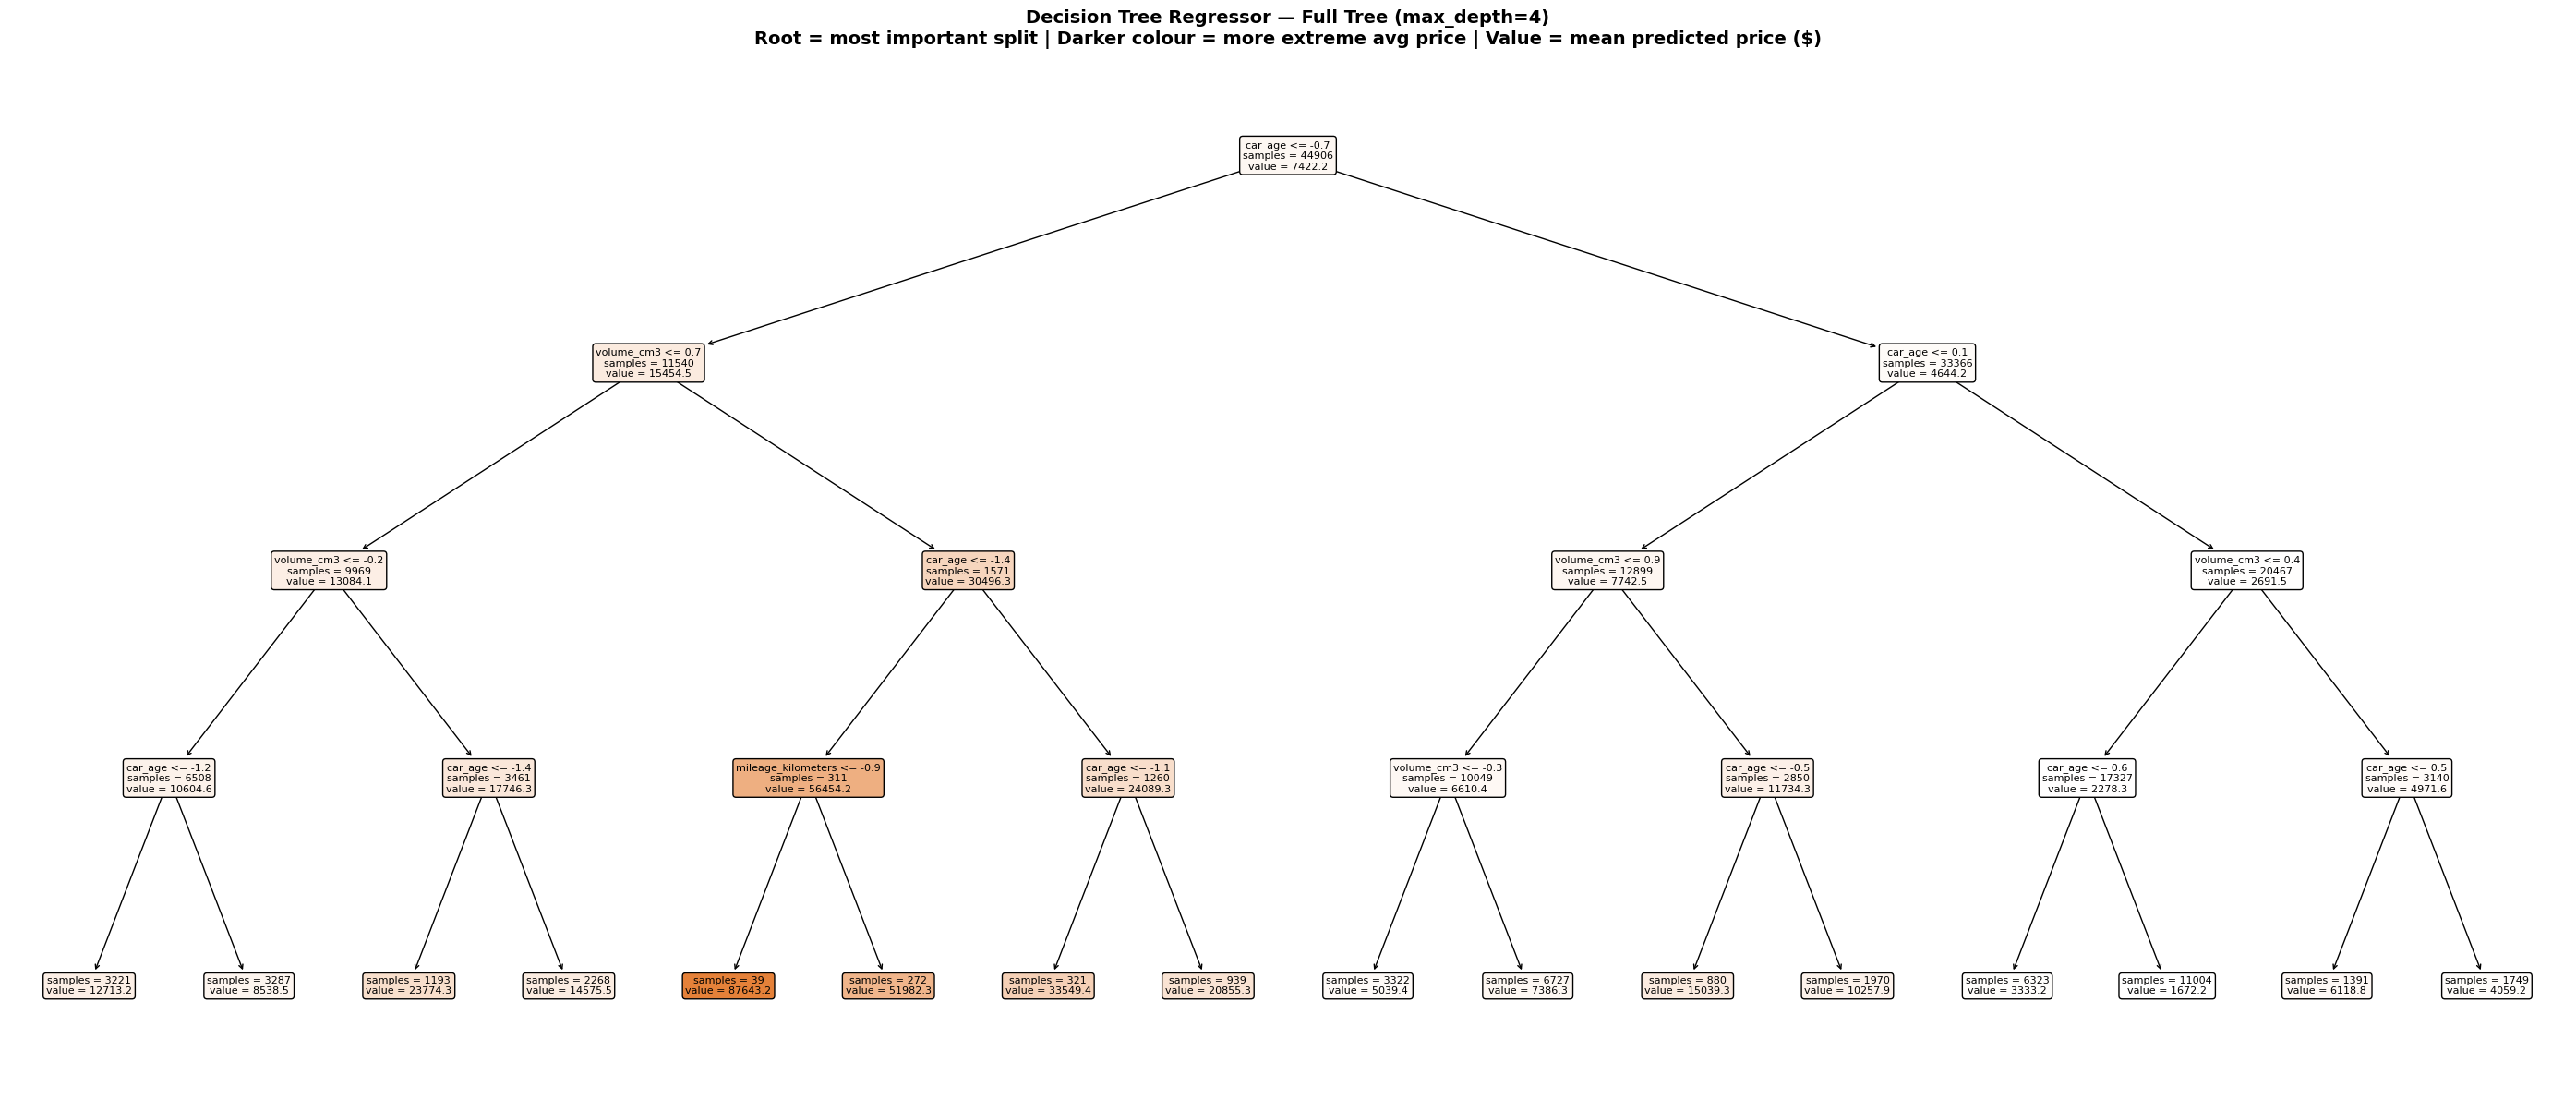

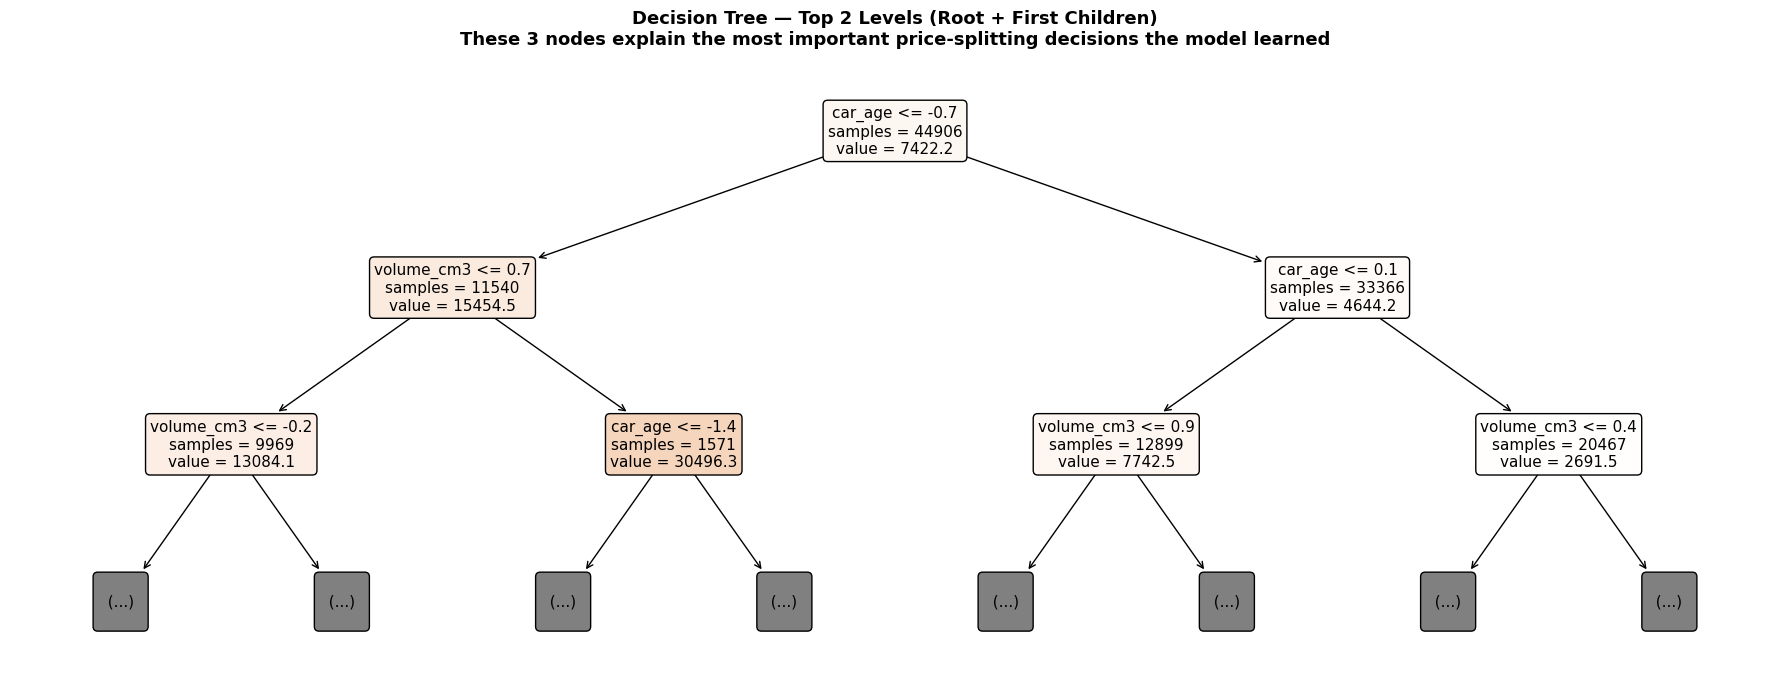

In [0]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# ── Full tree visualization (max_depth=4, our trained tree) ──
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    dt_model,
    feature_names = feature_names,
    max_depth     = 4,
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax,
    impurity      = False,   # hide MSE — keeps nodes clean and readable
    precision     = 1
)
ax.set_title(
    'Decision Tree Regressor — Full Tree (max_depth=4)\n'
    'Root = most important split | Darker colour = more extreme avg price | Value = mean predicted price ($)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Zoomed view: top 2 levels only for clarity ──
fig2, ax2 = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_model,
    feature_names = feature_names,
    max_depth     = 2,       # top 2 levels = root + first layer of children
    filled        = True,
    rounded       = True,
    fontsize      = 11,
    ax            = ax2,
    impurity      = False,
    precision     = 1
)
ax2.set_title(
    'Decision Tree — Top 2 Levels (Root + First Children)\n'
    'These 3 nodes explain the most important price-splitting decisions the model learned',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()



## 7. Model Comparison

In [0]:
all_results = [lr_results, rf_results, xgb_results, dt_results]
results_df  = pd.DataFrame(all_results)

print("\n" + "=" * 110)
print("  MODEL COMPARISON — Train vs Test  (MAE · RMSE · R²)")
print("=" * 110)
print(f"{'Model':<22} {'Train MAE':>11} {'Test MAE':>11} {'MAE Gap':>10} {'Train RMSE':>12} {'Test RMSE':>11} {'Train R²':>9} {'Test R²':>9} {'Overfit':>10}")
print("-" * 110)
for _, row in results_df.iterrows():
    print(f"{row['model']:<22} ${row['train_mae']:>9,.0f} ${row['test_mae']:>9,.0f} ${row['mae_gap']:>+8,.0f} ${row['train_rmse']:>10,.0f} ${row['test_rmse']:>9,.0f}  {row['train_r2']:>8.4f}  {row['test_r2']:>8.4f} {row['overfitting']:>10}")

# Best model by test RMSE (primary metric)
best_mae_idx  = results_df['test_mae'].idxmin()
best_rmse_idx = results_df['test_rmse'].idxmin()
best_mae_name  = results_df.loc[best_mae_idx,  'model']
best_rmse_name = results_df.loc[best_rmse_idx, 'model']

print(f"\n{'*' * 110}")
print(f"  Best model by test MAE:  {best_mae_name}  (MAE = ${results_df.loc[best_mae_idx,  'test_mae']:,.0f})")
print(f"  Best model by test RMSE: {best_rmse_name}  (RMSE = ${results_df.loc[best_rmse_idx, 'test_rmse']:,.0f})")
print(f"{'*' * 110}")
print()
print("  NOTE: R² is shown for reference only — it is NOT used for model selection.")
print("  R² measures how much of the variance (price spread) the model explains.")
print("  On a right-skewed distribution ($500–$118k+), luxury outliers inflate R²,")
print("  making a model look better than it really is for everyday mid-range cars.")
print("  RMSE is our primary metric — it penalises large errors and is dollar-interpretable.")


  MODEL COMPARISON — Train vs Test  (MAE · RMSE · R²)
Model                    Train MAE    Test MAE    MAE Gap   Train RMSE   Test RMSE  Train R²   Test R²    Overfit
--------------------------------------------------------------------------------------------------------------
Linear Regression      $    2,656 $    2,607 $     -49 $     5,548 $    5,235    0.5603    0.5861         OK
Random Forest          $    1,512 $    1,539 $     +26 $     3,446 $    3,382    0.8304    0.8272         OK
XGBoost                $    1,159 $    1,219 $     +60 $     2,098 $    2,551    0.9371    0.9017         OK
Decision Tree          $    2,171 $    2,153 $     -18 $     4,369 $    4,368    0.7273    0.7118         OK

**************************************************************************************************************
  Best model by test MAE:  XGBoost  (MAE = $1,219)
  Best model by test RMSE: XGBoost  (RMSE = $2,551)
*********************************************************************

## 8. Save Models to DBFS

In [0]:
# Save models to MLflow (NB07 loads them from MLflow)
mlflow.set_tracking_uri("databricks")

# Use the notebook's own path as the experiment — this always works on Databricks
notebook_path = dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get()
mlflow.set_experiment(notebook_path)

trained_models = {
    "linear_regression": lr_model,
    "random_forest":     rf_model,
    "xgboost":           xgb_model,
    "decision_tree":     dt_model,
}

for run_name, model in trained_models.items():
    with mlflow.start_run(run_name=run_name):
        mlflow.sklearn.log_model(model, artifact_path=run_name)
        # Match model name to results_df row
        row = results_df[results_df['model'].str.lower().str.replace(' ', '_') == run_name].iloc[0]
        # Log primary metrics (RMSE, MAE)
        mlflow.log_metric("train_mae",  row['train_mae'])
        mlflow.log_metric("train_rmse", row['train_rmse'])
        mlflow.log_metric("test_mae",   row['test_mae'])
        mlflow.log_metric("test_rmse",  row['test_rmse'])
        mlflow.log_metric("mae_gap",    row['mae_gap'])
        # Log R² for reference (not used for model selection)
        mlflow.log_metric("train_r2",   row['train_r2'])
        mlflow.log_metric("test_r2",    row['test_r2'])
        print(f"✓ Logged {run_name} to MLflow (test RMSE = ${row['test_rmse']:,.0f} | test R² = {row['test_r2']:.4f})")

print("\nAll 4 models saved to MLflow successfully.")

2026/04/21 18:52:23 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.


✓ Logged linear_regression to MLflow (test RMSE = $5,235 | test R² = 0.5861)


2026/04/21 18:52:26 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.


✓ Logged random_forest to MLflow (test RMSE = $3,382 | test R² = 0.8272)


2026/04/21 18:52:29 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.


✓ Logged xgboost to MLflow (test RMSE = $2,551 | test R² = 0.9017)


2026/04/21 18:52:33 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.


✓ Logged decision_tree to MLflow (test RMSE = $4,368 | test R² = 0.7118)

All 4 models saved to MLflow successfully.


## 9. Save Metrics to Catalog

In [0]:
# Save metrics as Delta table (includes R² columns and all 4 models)
metrics_spark = spark.createDataFrame(results_df)
metrics_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.default.carprice_project_trained_models")

# Verify
verify = spark.table("workspace.default.carprice_project_trained_models")
print("Saved carprice_project_trained_models table (4 models, includes R²):")
verify.show(truncate=False)

Saved carprice_project_trained_models table (4 models, includes R²):
+-----------------+---------+----------+--------+---------+--------+-------+-------+-----------+
|model            |train_mae|train_rmse|test_mae|test_rmse|train_r2|test_r2|mae_gap|overfitting|
+-----------------+---------+----------+--------+---------+--------+-------+-------+-----------+
|Linear Regression|2656.49  |5548.36   |2607.2  |5234.63  |0.5603  |0.5861 |-49.29 |OK         |
|Random Forest    |1512.03  |3446.19   |1538.52 |3382.45  |0.8304  |0.8272 |26.49  |OK         |
|XGBoost          |1158.6   |2097.64   |1218.92 |2551.37  |0.9371  |0.9017 |60.31  |OK         |
|Decision Tree    |2170.64  |4369.29   |2152.85 |4368.35  |0.7273  |0.7118 |-17.79 |OK         |
+-----------------+---------+----------+--------+---------+--------+-------+-------+-----------+

